C:\Users\Marcos\AppData\Local\Temp\ipykernel_19392\1218073272.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artistas.values, y=top_artistas.index, palette='magma')


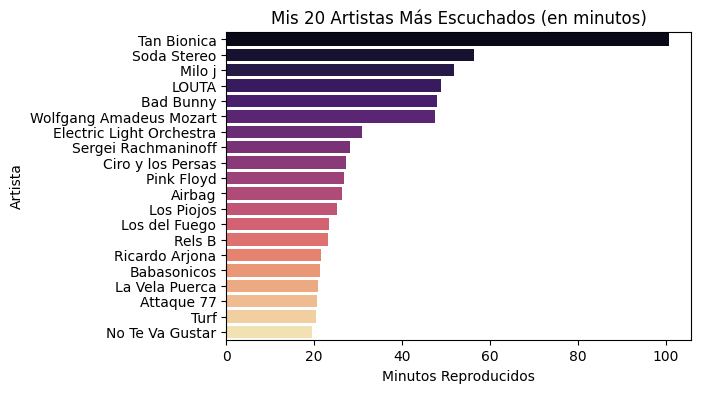

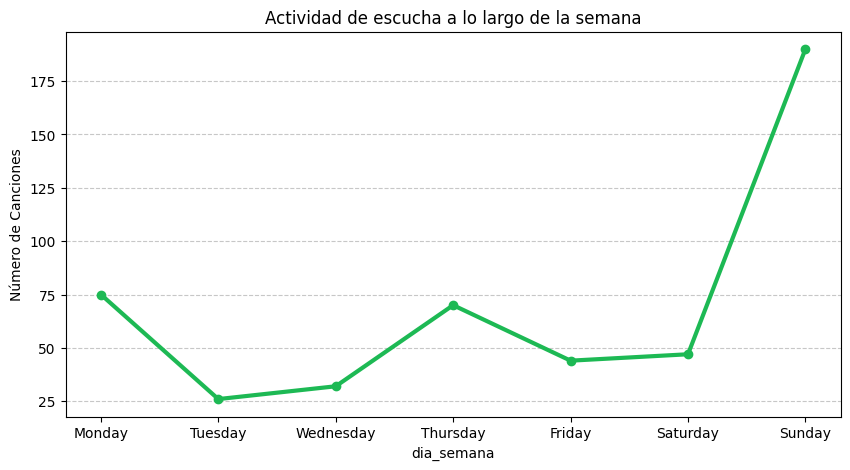

C:\Users\Marcos\AppData\Local\Temp\ipykernel_19392\1218073272.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=comparativa, x='artista', palette='viridis')


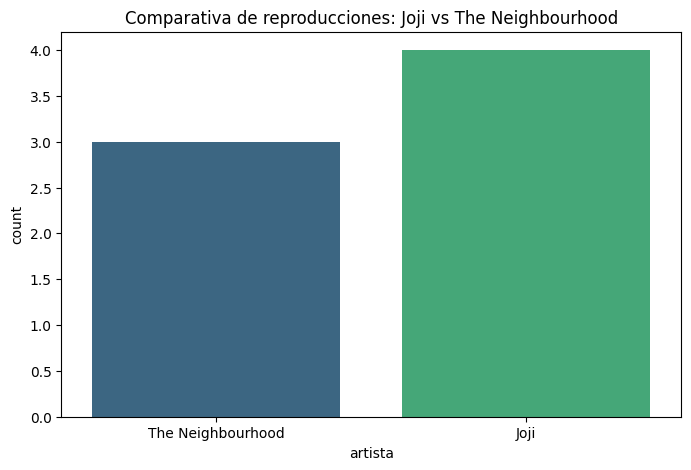

¡Datos cargados con éxito!


,fecha,cancion,artista,ms,minutos,dia_semana
0,2026-01-03,Lost in Translation,The Neighbourhood,190227,3.170450,Saturday
1,2026-01-03,Will He,Joji,161192,2.686533,Saturday
2,2026-01-03,Will He,Joji,40930,0.682167,Saturday
3,2026-01-03,Wonderwall - Remastered,Oasis,258773,4.312883,Saturday
4,2026-01-03,Peperina,Serú Girán,220280,3.671333,Saturday
5,2026-01-03,A la Orilla de la Chimenea,Joaquín Sabina,246507,4.108450,Saturday
6,2026-01-03,Magia Blanca,Turf,261973,4.366217,Saturday
7,2026-01-03,Imágenes Retro - Remasterizado 2007,Soda Stereo,229813,3.830217,Saturday
8,2026-01-03,Morir Enamorado,Jairo,226880,3.781333,Saturday
9,2026-01-03,Ese Maldito Momento,No Te Va Gustar,185867,3.097783,Saturday


In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga directa con Pandas (más rápido para estos archivos)
try:
    df = pd.read_json('data/Streaming_History_Audio_2026_1.json')
    
    # 2. Selección de columnas (asegurándonos de que existan)
    columnas_deseadas = {
        'ts': 'fecha',
        'master_metadata_track_name': 'cancion',
        'master_metadata_album_artist_name': 'artista',
        'ms_played': 'ms'
    }
    
    # Filtramos solo las que existen en el archivo para evitar errores
    columnas_reales = [c for c in columnas_deseadas.keys() if c in df.columns]
    df = df[columnas_reales].rename(columns=columnas_deseadas)

    # Convertir a formato fecha y extraer solo el día
    df['fecha'] = pd.to_datetime(df['fecha']).dt.date

    # Convertir milisegundos a minutos para que los números tengan sentido
    df['minutos'] = df['ms'] / 60000    

    # Agrupar por artista y sumar los minutos
    top_artistas = df.groupby('artista')['minutos'].sum().sort_values(ascending=False).head(20)

    # Crear el gráfico
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_artistas.values, y=top_artistas.index, palette='magma')

    plt.title('Mis 20 Artistas Más Escuchados (en minutos)')
    plt.xlabel('Minutos Reproducidos')
    plt.ylabel('Artista')
    plt.show()
    
    # Crear columna de día de la semana
    df['dia_semana'] = pd.to_datetime(df['fecha']).dt.day_name()

    # Contar cuántas canciones escuchaste por día
    orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    escuchas_por_dia = df['dia_semana'].value_counts().reindex(orden_dias)

    plt.figure(figsize=(10, 5))
    escuchas_por_dia.plot(kind='line', marker='o', color='#1DB954', lw=3) # Color verde Spotify

    plt.title('Actividad de escucha a lo largo de la semana')
    plt.ylabel('Número de Canciones')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # 1. Filtramos dos artistas para comparar
    comparativa = df[df['artista'].isin(['Joji', 'The Neighbourhood'])]

    # 2. Creamos un gráfico de conteo
    plt.figure(figsize=(8,5))
    sns.countplot(data=comparativa, x='artista', palette='viridis')

    plt.title('Comparativa de reproducciones: Joji vs The Neighbourhood')
    plt.show()

    # MOSTRAR RESULTADO
    print("¡Datos cargados con éxito!")
    display(df.head(20)) # 'display' es mejor que 'print' en Notebooks

except Exception as e:
    print(f"Ocurrió un error: {e}")


